Diagram saved to: /mnt/data/eeg_denoise_model_diagram.png
Notebook saved to: /mnt/data/eeg_denoise_architecture.ipynb


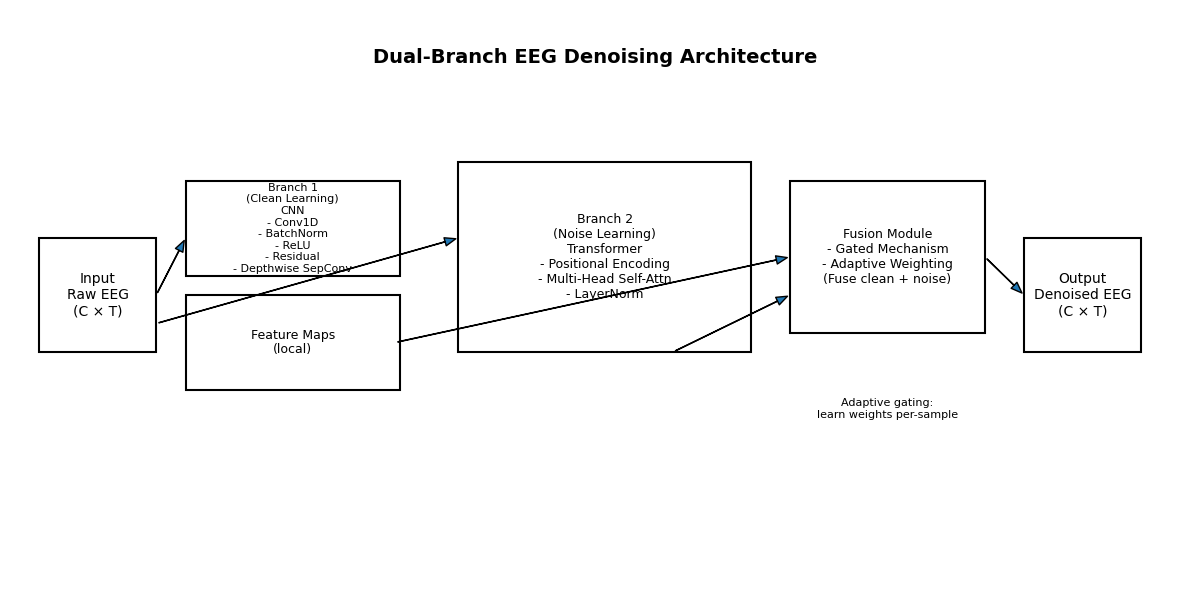

In [7]:
# Creating a Jupyter notebook (.ipynb) that draws a visual diagram of the Dual-Branch EEG denoising model.
# The notebook will also save a PNG image of the diagram.
# This code will:
# 1. Generate the diagram using matplotlib.
# 2. Save the diagram as '/mnt/data/eeg_denoise_model_diagram.png'.
# 3. Create a .ipynb file '/mnt/data/eeg_denoise_architecture.ipynb' that contains the plotting code and a short description.
# After execution, links to the created files will be provided.

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyArrowPatch, ArrowStyle
import nbformat
from nbformat.v4 import new_notebook, new_markdown_cell, new_code_cell
import os

# --- Part 1: function to draw the architecture diagram ---
def draw_eeg_dual_branch_diagram(save_path=None, figsize=(12,6)):
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_xlim(0, 12)
    ax.set_ylim(0, 6)
    ax.axis('off')

    # Helper to draw box with text (no explicit colors set)
    def box(x, y, w, h, text, fontsize=10):
        rect = Rectangle((x, y), w, h, fill=False, linewidth=1.5)
        ax.add_patch(rect)
        ax.text(x + w/2, y + h/2, text, ha='center', va='center', fontsize=fontsize, wrap=True)

    # Input
    box(0.3, 2.4, 1.2, 1.2, 'Input\nRaw EEG\n(C × T)', fontsize=10)

    # Branch 1 - Clean Learning (CNN)
    box(1.8, 3.2, 2.2, 1.0, 'Branch 1\n(Clean Learning)\nCNN\n- Conv1D\n- BatchNorm\n- ReLU\n- Residual\n- Depthwise SepConv', fontsize=8)
    box(1.8, 2.0, 2.2, 1.0, 'Feature Maps\n(local)', fontsize=9)

    # Branch 2 - Noise Learning (Transformer)
    box(4.6, 2.4, 3.0, 2.0, 'Branch 2\n(Noise Learning)\nTransformer\n- Positional Encoding\n- Multi-Head Self-Attn\n- LayerNorm', fontsize=9)

    # Fusion Module
    box(8.0, 2.6, 2.0, 1.6, 'Fusion Module\n- Gated Mechanism\n- Adaptive Weighting\n(Fuse clean + noise)', fontsize=9)

    # Output
    box(10.4, 2.4, 1.2, 1.2, 'Output\nDenoised EEG\n(C × T)', fontsize=10)

    # Arrows: Input -> Branches
    arr_style = ArrowStyle("Simple", head_length=8, head_width=6)
    a1 = FancyArrowPatch((1.5, 3.0), (1.8, 3.6), arrowstyle=arr_style, linewidth=1.0)
    a2 = FancyArrowPatch((1.5, 2.7), (4.6, 3.6), arrowstyle=arr_style, linewidth=1.0)
    ax.add_patch(a1); ax.add_patch(a2)

    # Branch outputs -> Fusion arrows
    a3 = FancyArrowPatch((3.95, 2.5), (8.0, 3.4), arrowstyle=arr_style, linewidth=1.0)
    a4 = FancyArrowPatch((6.8, 2.4), (8.0, 3.0), arrowstyle=arr_style, linewidth=1.0)
    ax.add_patch(a3); ax.add_patch(a4)

    # Fusion -> Output
    a5 = FancyArrowPatch((10.0, 3.4), (10.4, 3.0), arrowstyle=arr_style, linewidth=1.0)
    ax.add_patch(a5)

    # Annotations for adaptive gating
    ax.text(9.0, 1.8, 'Adaptive gating:\nlearn weights per-sample', ha='center', va='center', fontsize=8)

    # Title
    ax.text(6, 5.5, 'Dual-Branch EEG Denoising Architecture', ha='center', va='center', fontsize=14, weight='bold')

    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=200, bbox_inches='tight')
    return fig, ax

# Create output directory
os.makedirs('/mnt/data', exist_ok=True)
png_path = '/mnt/data/eeg_denoise_model_diagram.png'

# Draw and save diagram
fig, ax = draw_eeg_dual_branch_diagram(save_path=png_path)

# --- Part 2: create a notebook (.ipynb) with the plotting code ---
nb = new_notebook()

md_text = """# EEG Denoising — Dual-Branch Model Diagram

Notebook created automatically. This notebook contains code to plot a visual diagram of a Dual-Branch EEG denoising model:
- Branch 1: CNN-based clean learning (local features)
- Branch 2: Transformer-based noise learning (long-term dependencies)
- Fusion: Gated / adaptive weighting mechanism

You can run the plotting cell below in a Jupyter environment (Python 3.12 compatible).
"""

code_text = '''import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyArrowPatch, ArrowStyle

def draw_eeg_dual_branch_diagram(save_path=None, figsize=(12,6)):
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_xlim(0, 12)
    ax.set_ylim(0, 6)
    ax.axis('off')

    def box(x, y, w, h, text, fontsize=10):
        rect = Rectangle((x, y), w, h, fill=False, linewidth=1.5)
        ax.add_patch(rect)
        ax.text(x + w/2, y + h/2, text, ha='center', va='center', fontsize=fontsize, wrap=True)

    box(0.3, 2.4, 1.2, 1.2, 'Input\\nRaw EEG\\n(C × T)', fontsize=10)
    box(1.8, 3.2, 2.2, 1.0, 'Branch 1\\n(Clean Learning)\\nCNN\\n- Conv1D\\n- BatchNorm\\n- ReLU\\n- Residual\\n- Depthwise SepConv', fontsize=8)
    box(1.8, 2.0, 2.2, 1.0, 'Feature Maps\\n(local)', fontsize=9)
    box(4.6, 2.4, 3.0, 2.0, 'Branch 2\\n(Noise Learning)\\nTransformer\\n- Positional Encoding\\n- Multi-Head Self-Attn\\n- LayerNorm', fontsize=9)
    box(8.0, 2.6, 2.0, 1.6, 'Fusion Module\\n- Gated Mechanism\\n- Adaptive Weighting\\n(Fuse clean + noise)', fontsize=9)
    box(10.4, 2.4, 1.2, 1.2, 'Output\\nDenoised EEG\\n(C × T)', fontsize=10)

    arr_style = ArrowStyle("Simple", head_length=8, head_width=6)
    a1 = FancyArrowPatch((1.5, 3.0), (1.8, 3.6), arrowstyle=arr_style, linewidth=1.0)
    a2 = FancyArrowPatch((1.5, 2.7), (4.6, 3.6), arrowstyle=arr_style, linewidth=1.0)
    ax.add_patch(a1); ax.add_patch(a2)

    a3 = FancyArrowPatch((3.95, 2.5), (8.0, 3.4), arrowstyle=arr_style, linewidth=1.0)
    a4 = FancyArrowPatch((6.8, 2.4), (8.0, 3.0), arrowstyle=arr_style, linewidth=1.0)
    ax.add_patch(a3); ax.add_patch(a4)

    a5 = FancyArrowPatch((10.0, 3.4), (10.4, 3.0), arrowstyle=arr_style, linewidth=1.0)
    ax.add_patch(a5)

    ax.text(9.0, 1.8, 'Adaptive gating:\\nlearn weights per-sample', ha='center', va='center', fontsize=8)
    ax.text(6, 5.5, 'Dual-Branch EEG Denoising Architecture', ha='center', va='center', fontsize=14, weight='bold')

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=200, bbox_inches='tight')
    return fig, ax

# Draw and display
fig, ax = draw_eeg_dual_branch_diagram()
plt.show()
'''

nb['cells'] = [new_markdown_cell(md_text), new_code_cell(code_text)]
nb_path = '/mnt/data/eeg_denoise_architecture.ipynb'
with open(nb_path, 'w', encoding='utf-8') as f:
    nbformat.write(nb, f)

# Outputs to user
print("Diagram saved to:", png_path)
print("Notebook saved to:", nb_path)

# Display the image inline as the visible output
plt.show()
